# 🍽️ Zomato Geospatial & NLP Analysis

## Project Overview

This project performs an end-to-end Exploratory Data Analysis (EDA) on the Zomato Bangalore restaurant dataset using SQL, Python, Natural Language Processing (NLP), and Geospatial Analysis.

### Objectives
- Understand restaurant trends across Bangalore
- Analyze the effect of online ordering on ratings
- Explore customer reviews using NLP
- Visualize restaurant locations using interactive maps
- Generate business insights from the data

### Technologies Used
- Python
- SQLite
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Geopy
- Folium

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 📂 Data Loading

The dataset is stored in an SQLite database. In this section, we load the restaurant data into a Pandas DataFrame for further analysis.

Dataset Link: https://www.kaggle.com/datasets/pandyaparam/zomato-rawdata-geo-data

In [ ]:
con = sqlite3.connect(r"/kaggle/input/datasets/pandyaparam/zomato-rawdata-geo-data/zomato_rawdata.sqlite") #True for my case, Change here if needed

In [3]:
pd.read_sql_query("SELECT * FROM Users" , con).head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [4]:
df = pd.read_sql_query("SELECT * FROM Users" , con)
df.shape

(51717, 18)

In [5]:
df.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [6]:
df.head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


## 🔍 Data Cleaning & Missing Value Analysis

Before performing analysis, we inspect the dataset for missing values and understand its overall structure.

In [7]:
df.isnull().sum()

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
df.isnull().sum()/len(df)*100

index                           0.000000
url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

## 📊 Online Ordering Analysis

This analysis investigates whether restaurants offering online ordering tend to receive higher customer ratings.

A normalized stacked bar chart is used to compare the proportion of online and offline restaurants across rating categories.

In [9]:
x = pd.crosstab(df['rate'] , df['online_order'])

In [10]:
x

online_order,No,Yes
rate,,
-,63,6
1.8 /5,3,0
1.8/5,2,0
2.0 /5,7,0
2.0/5,4,0
...,...,...
4.8 /5,23,20
4.8/5,11,12
4.9 /5,4,26


<Axes: xlabel='rate'>

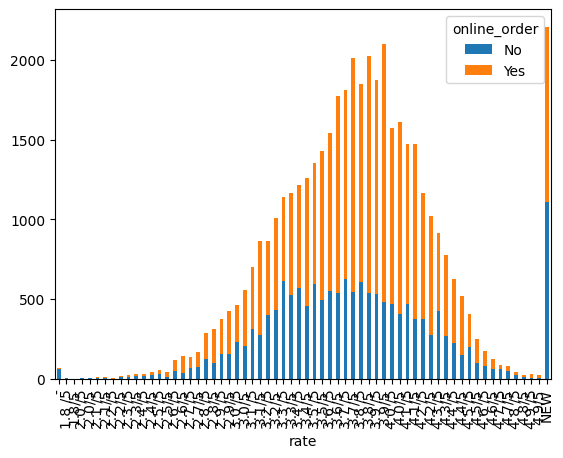

In [11]:
x.plot(kind='bar' , stacked=True) ## stacked=True gives basically stacked bar chart

In [12]:
x.sum(axis=1).astype(float)

rate
-           69.0
1.8 /5       3.0
1.8/5        2.0
2.0 /5       7.0
2.0/5        4.0
           ...  
4.8 /5      43.0
4.8/5       23.0
4.9 /5      30.0
4.9/5       25.0
NEW       2208.0
Length: 64, dtype: float64

In [13]:
normalize_df = x.div(x.sum(axis=1).astype(float) , axis=0)

<Axes: xlabel='rate'>

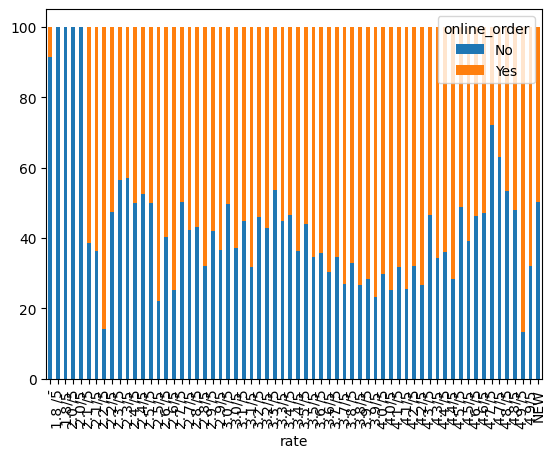

In [14]:
(normalize_df*100).plot(kind='bar' , stacked=True)

In [15]:
df['rest_type'].isnull().sum()

np.int64(227)

## 🍴 Restaurant Type Analysis

Restaurants are categorized based on their service type (Quick Bites, Casual Dining, Cafes, etc.).

This section focuses on Quick Bites, as they represent one of the largest restaurant categories in Bangalore.

In [16]:
data = df.dropna(subset=['rest_type'])

In [17]:
data['rest_type'].isnull().sum()

np.int64(0)

In [18]:
data['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Dhaba', 'Quick Bites, Sweet Shop',
       'Microbrewery', 'Food Court, Quick Bites', 'Pub, Bar',
       'Casual Dining, Pub', 'Lounge, Ba

In [19]:
quick_bites_df = data[data['rest_type'].str.contains('Quick Bites')]

In [20]:
quick_bites_df.shape

(20639, 18)

In [21]:
quick_bites_df.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

## 📝 Customer Review Preprocessing

Customer reviews are converted to lowercase and cleaned using regular expressions.

Stopwords are removed to retain only meaningful words for Natural Language Processing.

In [22]:
quick_bites_df['reviews_list']

3        [('Rated 4.0', "RATED\n  Great food and proper...
23       [('Rated 4.0', "RATED\n  So, went here with fr...
26       [('Rated 5.0', 'RATED\n  please provide some e...
31       [('Rated 1.0', "RATED\n  Worst restaurant ever...
34       [('Rated 3.0', 'RATED\n  Not worth for the mon...
                               ...                        
51641    [('Rated 2.0', "RATED\n  Food is not upto the ...
51642                                                   []
51643                                                   []
51644                                                   []
51645    [('Rated 5.0', "RATED\n  I was randomly lookin...
Name: reviews_list, Length: 20639, dtype: object

In [23]:
quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x:x.lower())

/tmp/ipykernel_58/4206969916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x:x.lower())


In [24]:
from nltk.corpus import RegexpTokenizer

In [25]:
tokenizer = RegexpTokenizer("[a-zA-Z]+")

In [26]:
tokenizer

RegexpTokenizer(pattern='[a-zA-Z]+', gaps=False, discard_empty=True, flags=re.UNICODE|re.MULTILINE|re.DOTALL)

In [27]:
tokenizer.tokenize(quick_bites_df['reviews_list'][3])

['rated',
 'rated',
 'n',
 'great',
 'food',
 'and',
 'proper',
 'karnataka',
 'style',
 'full',
 'meals',
 'been',
 'there',
 'twice',
 'and',
 'was',
 'fully',
 'satisfied',
 'will',
 'give',
 'stars',
 'if',
 'it',
 's',
 'well',
 'managed',
 'rated',
 'rated',
 'n',
 'reached',
 'the',
 'place',
 'at',
 'pm',
 'on',
 'saturday',
 'half',
 'of',
 'the',
 'items',
 'on',
 'the',
 'menu',
 'were',
 'over',
 'what',
 'was',
 'annoying',
 'was',
 'is',
 'the',
 'food',
 'was',
 'cold',
 'the',
 'taste',
 'was',
 'also',
 'very',
 'average',
 'only',
 'dosa',
 'and',
 'holige',
 'were',
 'good',
 'there',
 'were',
 'very',
 'few',
 'people',
 'in',
 'the',
 'restaurant',
 'and',
 'the',
 'service',
 'was',
 'still',
 'very',
 'slow',
 'the',
 'waiters',
 'were',
 'all',
 'standing',
 'in',
 'one',
 'corner',
 'and',
 'talking',
 'had',
 'to',
 'call',
 'them',
 'repeatedly',
 'rated',
 'rated',
 'n',
 'had',
 'been',
 'here',
 'good',
 'food',
 'served',
 'and',
 'tasty',
 'good',
 'plac

In [28]:
sample = data[0:10000]
reviews_tokens = sample['reviews_list'].apply(tokenizer.tokenize)

In [29]:
reviews_tokens

0        [Rated, RATED, n, A, beautiful, place, to, din...
1        [Rated, RATED, n, Had, been, here, for, dinner...
2        [Rated, RATED, n, Ambience, is, not, that, goo...
3        [Rated, RATED, n, Great, food, and, proper, Ka...
4        [Rated, RATED, n, Very, good, restaurant, in, ...
                               ...                        
10046    [Rated, RATED, n, A, simplistic, joy, for, loc...
10047                              [Rated, RATED, n, Good]
10048    [Rated, RATED, n, Vry, gud, taste, and, someth...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [30]:
from nltk.corpus import stopwords

In [31]:
stop = stopwords.words('english')
stop.extend(['rated' , "n" , "nan" , "x" , "RATED" , "Rated"])

In [32]:
reviews_tokens

0        [Rated, RATED, n, A, beautiful, place, to, din...
1        [Rated, RATED, n, Had, been, here, for, dinner...
2        [Rated, RATED, n, Ambience, is, not, that, goo...
3        [Rated, RATED, n, Great, food, and, proper, Ka...
4        [Rated, RATED, n, Very, good, restaurant, in, ...
                               ...                        
10046    [Rated, RATED, n, A, simplistic, joy, for, loc...
10047                              [Rated, RATED, n, Good]
10048    [Rated, RATED, n, Vry, gud, taste, and, someth...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [33]:
rev3 = reviews_tokens[3]

In [34]:
print([token for token in rev3 if token not in stop])

['Great', 'food', 'proper', 'Karnataka', 'style', 'full', 'meals', 'Been', 'twice', 'fully', 'satisfied', 'Will', 'give', 'stars', 'well', 'managed', 'Reached', 'place', 'pm', 'Saturday', 'Half', 'items', 'menu', 'What', 'annoying', 'food', 'cold', 'The', 'taste', 'also', 'average', 'Only', 'dosa', 'holige', 'good', 'There', 'people', 'restaurant', 'service', 'still', 'slow', 'The', 'waiters', 'standing', 'one', 'corner', 'talking', 'Had', 'call', 'repeatedly', 'Had', 'good', 'food', 'served', 'tasty', 'good', 'place', 'go', 'freinds', 'family', 'first', 'get', 'served', 'well', 'food', 'One', 'good', 'hotel', 'price', 'How', 'Udupi', 'restaurant', 'dirty', 'floor', 'walls', 'waiters', 'stained', 'food', 'Why', 'cant', 'clean', 'The', 'floor', 'even', 'decorative', 'colour', 'paper', 'every', 'lot', 'food', 'Now', 'coming', 'taste', 'food', 'pretty', 'decent', 'chargw', 'What', 'upset', 'us', 'menu', 'says', 'serve', 'thambuli', 'two', 'variety', 'rice', 'etc', 'still', 'charged', 'us'

In [35]:
reviews_tokens_clean = reviews_tokens.apply(lambda each_review : [token for token in each_review if token not in stop])

In [36]:
reviews_tokens_clean

0        [A, beautiful, place, dine, The, interiors, ta...
1        [Had, dinner, family, Turned, good, choose, su...
2        [Ambience, good, enough, pocket, friendly, caf...
3        [Great, food, proper, Karnataka, style, full, ...
4        [Very, good, restaurant, neighbourhood, Buffet...
                               ...                        
10046    [A, simplistic, joy, local, biryani, lovers, n...
10047                                               [Good]
10048    [Vry, gud, taste, something, different, must, ...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [37]:
total_reviews_2D = list(reviews_tokens_clean)

In [38]:
total_reviews_1D = []

for review in total_reviews_2D:
    for word in review:
        total_reviews_1D.append(word)

In [39]:
total_reviews_1D

['A',
 'beautiful',
 'place',
 'dine',
 'The',
 'interiors',
 'take',
 'back',
 'Mughal',
 'era',
 'The',
 'lightings',
 'perfect',
 'We',
 'went',
 'occasion',
 'Christmas',
 'limited',
 'items',
 'available',
 'But',
 'taste',
 'service',
 'compromised',
 'The',
 'complaint',
 'breads',
 'could',
 'better',
 'Would',
 'surely',
 'like',
 'come',
 'I',
 'dinner',
 'family',
 'weekday',
 'The',
 'restaurant',
 'completely',
 'empty',
 'Ambience',
 'good',
 'good',
 'old',
 'hindi',
 'music',
 'Seating',
 'arrangement',
 'good',
 'We',
 'ordered',
 'masala',
 'papad',
 'panner',
 'baby',
 'corn',
 'starters',
 'lemon',
 'corrionder',
 'soup',
 'butter',
 'roti',
 'olive',
 'chilli',
 'paratha',
 'Food',
 'fresh',
 'good',
 'service',
 'good',
 'Good',
 'family',
 'hangout',
 'nCheers',
 'Its',
 'restaurant',
 'near',
 'Banashankari',
 'BDA',
 'Me',
 'along',
 'office',
 'friends',
 'visited',
 'buffet',
 'unfortunately',
 'provide',
 'veg',
 'buffet',
 'On',
 'inquiring',
 'said',
 'pla

## 📈 Word Frequency Analysis

The cleaned review corpus is analyzed to identify the most frequently occurring words.

This helps identify common customer opinions and restaurant characteristics.

In [40]:
from nltk import FreqDist

In [41]:
fd = FreqDist()
for word in total_reviews_1D:
    fd[word] = fd[word] + 1

In [42]:
fd.most_common(20)

[('place', 139173),
 ('I', 137965),
 ('good', 134232),
 ('food', 126195),
 ('The', 97479),
 ('chicken', 46887),
 ('service', 41216),
 ('taste', 40063),
 ('ordered', 39651),
 ('great', 34402),
 ('really', 33942),
 ('time', 33052),
 ('try', 32415),
 ('one', 32079),
 ('ambience', 31703),
 ('like', 30679),
 ('also', 30647),
 ('It', 30487),
 ('visit', 27355),
 ('restaurant', 26421)]

<Axes: xlabel='Samples', ylabel='Counts'>

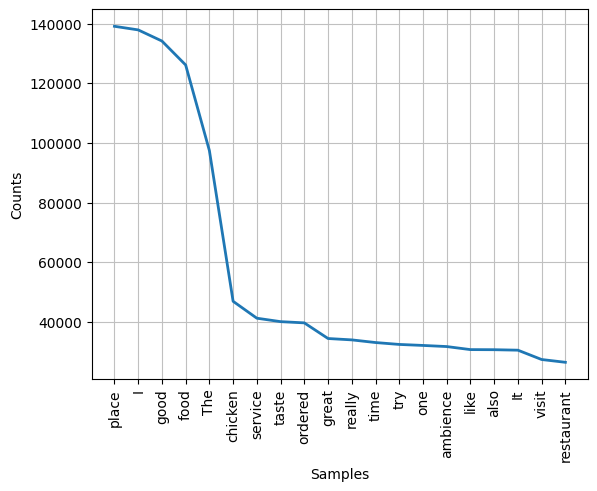

In [43]:
fd.plot(20)

In [44]:
from nltk import FreqDist , bigrams , trigrams

## 🔗 Bigram & Trigram Analysis

Instead of analyzing individual words, this section identifies frequently occurring word pairs (bigrams) and word triplets (trigrams).

These combinations reveal meaningful customer phrases such as:

- good food
- highly recommended
- worth visit

In [45]:
bi_grams = bigrams(total_reviews_1D)

In [46]:
bi_grams

<generator object bigrams at 0x7d404e68f140>

In [47]:
fd_bigrams = FreqDist()

for bigram in bi_grams:
    fd_bigrams[bigram] = fd_bigrams[bigram] + 1

In [48]:
fd_bigrams.most_common(20)

[(('The', 'food'), 10497),
 (('I', 'ordered'), 10159),
 (('really', 'good'), 9575),
 (('This', 'place'), 8208),
 (('must', 'try'), 7824),
 (('I', 'would'), 7353),
 (('We', 'ordered'), 7223),
 (('visit', 'place'), 6897),
 (('food', 'good'), 6823),
 (('good', 'food'), 6482),
 (('The', 'place'), 6158),
 (('main', 'course'), 5544),
 (('non', 'veg'), 5364),
 (('good', 'place'), 5339),
 (('ice', 'cream'), 5287),
 (('also', 'good'), 5083),
 (('The', 'ambience'), 4798),
 (('I', 'tried'), 4523),
 (('good', 'I'), 4139),
 (('good', 'The'), 4078)]

<Axes: xlabel='Samples', ylabel='Counts'>

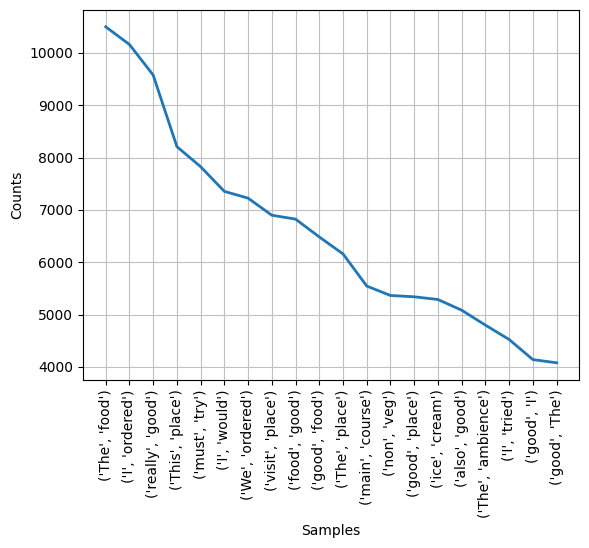

In [49]:
fd_bigrams.plot(20)

In [50]:
fd_bigrams.most_common(100)

[(('The', 'food'), 10497),
 (('I', 'ordered'), 10159),
 (('really', 'good'), 9575),
 (('This', 'place'), 8208),
 (('must', 'try'), 7824),
 (('I', 'would'), 7353),
 (('We', 'ordered'), 7223),
 (('visit', 'place'), 6897),
 (('food', 'good'), 6823),
 (('good', 'food'), 6482),
 (('The', 'place'), 6158),
 (('main', 'course'), 5544),
 (('non', 'veg'), 5364),
 (('good', 'place'), 5339),
 (('ice', 'cream'), 5287),
 (('also', 'good'), 5083),
 (('The', 'ambience'), 4798),
 (('I', 'tried'), 4523),
 (('good', 'I'), 4139),
 (('good', 'The'), 4078),
 (('food', 'I'), 3998),
 (('place', 'I'), 3896),
 (('The', 'service'), 3830),
 (('one', 'best'), 3711),
 (('must', 'visit'), 3658),
 (('I', 'love'), 3529),
 (('quality', 'food'), 3510),
 (('nWe', 'ordered'), 3490),
 (('time', 'I'), 3398),
 (('nice', 'place'), 3290),
 (('The', 'staff'), 3286),
 (('taste', 'good'), 3275),
 (('pretty', 'good'), 3270),
 (('fried', 'rice'), 3127),
 (('pocket', 'friendly'), 3097),
 (('place', 'good'), 3083),
 (('I', 'loved'), 

In [51]:
tri_grams = trigrams(total_reviews_1D)

In [52]:
fd_trigrams = FreqDist()

for trigram in tri_grams:
    fd_trigrams[trigram] = fd_trigrams[trigram] + 1

In [53]:
fd_trigrams.most_common(50)

[(('veg', 'non', 'veg'), 1525),
 (('must', 'visit', 'place'), 1487),
 (('The', 'food', 'good'), 1339),
 (('place', 'hangout', 'friends'), 1165),
 (('I', 'must', 'say'), 1131),
 (('I', 'would', 'recommend'), 1059),
 (('I', 'visited', 'place'), 1054),
 (('I', 'would', 'say'), 979),
 (('place', 'hang', 'friends'), 967),
 (('food', 'really', 'good'), 886),
 (('nFood', 'nAmbience', 'nService'), 845),
 (('A', 'must', 'visit'), 768),
 (('The', 'ambience', 'good'), 751),
 (('A', 'good', 'place'), 737),
 (('North', 'Indian', 'food'), 675),
 (('I', 'would', 'like'), 619),
 (('nFood', 'nService', 'nAmbience'), 607),
 (('A', 'must', 'try'), 603),
 (('I', 'really', 'liked'), 595),
 (('I', 'ordered', 'chicken'), 582),
 (('first', 'time', 'I'), 570),
 (('The', 'staff', 'friendly'), 561),
 (('The', 'best', 'part'), 561),
 (('The', 'food', 'really'), 559),
 (('Overall', 'good', 'experience'), 558),
 (('I', 'love', 'place'), 554),
 (('paneer', 'butter', 'masala'), 554),
 (('really', 'good', 'The'), 552)

In [54]:
df.head(3)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


## 🌍 Geospatial Analysis

Restaurant locations are converted into latitude and longitude coordinates using the Geopy library.

These coordinates are later used to visualize restaurant density and geographical patterns across Bangalore.

In [55]:
!pip install geocoder
!pip install geopy

In [56]:
df['location']

0                      Banashankari
1                      Banashankari
2                      Banashankari
3                      Banashankari
4                      Basavanagudi
                    ...            
51712                    Whitefield
51713                    Whitefield
51714                    Whitefield
51715    ITPL Main Road, Whitefield
51716    ITPL Main Road, Whitefield
Name: location, Length: 51717, dtype: object

In [57]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', None, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan

In [58]:
len(df['location'].unique())

94

In [59]:
df['location'] = df['location'] + " , Bangalore  , Karnataka , India "

In [60]:
df['location']

0           Banashankari , Bangalore  , Karnataka , India 
1           Banashankari , Bangalore  , Karnataka , India 
2           Banashankari , Bangalore  , Karnataka , India 
3           Banashankari , Bangalore  , Karnataka , India 
4           Basavanagudi , Bangalore  , Karnataka , India 
                               ...                        
51712         Whitefield , Bangalore  , Karnataka , India 
51713         Whitefield , Bangalore  , Karnataka , India 
51714         Whitefield , Bangalore  , Karnataka , India 
51715    ITPL Main Road, Whitefield , Bangalore  , Karn...
51716    ITPL Main Road, Whitefield , Bangalore  , Karn...
Name: location, Length: 51717, dtype: object

In [61]:
df['location'].unique()

array(['Banashankari , Bangalore  , Karnataka , India ',
       'Basavanagudi , Bangalore  , Karnataka , India ',
       'Mysore Road , Bangalore  , Karnataka , India ',
       'Jayanagar , Bangalore  , Karnataka , India ',
       'Kumaraswamy Layout , Bangalore  , Karnataka , India ',
       'Rajarajeshwari Nagar , Bangalore  , Karnataka , India ',
       'Vijay Nagar , Bangalore  , Karnataka , India ',
       'Uttarahalli , Bangalore  , Karnataka , India ',
       'JP Nagar , Bangalore  , Karnataka , India ',
       'South Bangalore , Bangalore  , Karnataka , India ',
       'City Market , Bangalore  , Karnataka , India ',
       'Nagarbhavi , Bangalore  , Karnataka , India ',
       'Bannerghatta Road , Bangalore  , Karnataka , India ',
       'BTM , Bangalore  , Karnataka , India ',
       'Kanakapura Road , Bangalore  , Karnataka , India ',
       'Bommanahalli , Bangalore  , Karnataka , India ', nan,
       'CV Raman Nagar , Bangalore  , Karnataka , India ',
       'Electronic Ci

In [62]:
df_copy = df.copy()

In [63]:
df_copy['location'].isnull().sum()

np.int64(21)

In [64]:
df_copy = df_copy.dropna(subset=['location'])

In [65]:
df_copy['location'].isnull().sum()

np.int64(0)

In [66]:
locations = pd.DataFrame(df_copy['location'].unique())

In [67]:
locations.columns = ['name']

> **Note**

 Free OpenStreetMap (Nominatim) servers may occasionally timeout due to request limits.

 For production environments, it is recommended to cache coordinates or use a paid geocoding API.

In [68]:
from geopy.geocoders import Nominatim

In [69]:
geolocator = Nominatim(user_agent="app" , timeout=None)

In [70]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import numpy as np
import time

# Initialize geocoder
geolocator = Nominatim(
    user_agent="zomato_geocoder",
    timeout=10
)

# Rate limiter
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=2,
    max_retries=3,
    error_wait_seconds=5,
    swallow_exceptions=True
)

lat = []
lon = []

total = len(locations)

for i, place in enumerate(locations['name'], start=1):

    print(f"Processing {i}/{total}: {place}")

    try:
        location = geocode(place)

        if location:
            lat.append(location.latitude)
            lon.append(location.longitude)
        else:
            lat.append(np.nan)
            lon.append(np.nan)

    except Exception as e:
        print(f"Error: {place} -> {e}")
        lat.append(np.nan)
        lon.append(np.nan)

# Save after all locations are processed
locations["lat"] = lat
locations["lon"] = lon

locations.to_csv("locations_with_coordinates.csv", index=False)

print("Completed Successfully!")

Processing 1/93: Banashankari , Bangalore  , Karnataka , India 
Processing 2/93: Basavanagudi , Bangalore  , Karnataka , India 
Processing 3/93: Mysore Road , Bangalore  , Karnataka , India 
Processing 4/93: Jayanagar , Bangalore  , Karnataka , India 
Processing 5/93: Kumaraswamy Layout , Bangalore  , Karnataka , India 
Processing 6/93: Rajarajeshwari Nagar , Bangalore  , Karnataka , India 
Processing 7/93: Vijay Nagar , Bangalore  , Karnataka , India 
Processing 8/93: Uttarahalli , Bangalore  , Karnataka , India 
Processing 9/93: JP Nagar , Bangalore  , Karnataka , India 
Processing 10/93: South Bangalore , Bangalore  , Karnataka , India 
Processing 11/93: City Market , Bangalore  , Karnataka , India 
Processing 12/93: Nagarbhavi , Bangalore  , Karnataka , India 
Processing 13/93: Bannerghatta Road , Bangalore  , Karnataka , India 
Processing 14/93: BTM , Bangalore  , Karnataka , India 
Processing 15/93: Kanakapura Road , Bangalore  , Karnataka , India 
Processing 16/93: Bommanahalli 

In [71]:
locations['latitude'] = lat
locations['longitude'] = lon

In [72]:
locations

,name,lat,lon,latitude,longitude
0,"Banashankari , Bangalore , Karnataka , India",12.927820,77.556621,12.927820,77.556621
1,"Basavanagudi , Bangalore , Karnataka , India",12.941726,77.575502,12.941726,77.575502
2,"Mysore Road , Bangalore , Karnataka , India",12.946703,77.530070,12.946703,77.530070
3,"Jayanagar , Bangalore , Karnataka , India",12.929273,77.582423,12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore , Karnataka , ...",12.915040,77.567888,12.915040,77.567888
...,...,...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",13.022235,77.567183,13.022235,77.567183
89,"Magadi Road , Bangalore , Karnataka , India",12.975653,77.555355,12.975653,77.555355
90,"Yelahanka , Bangalore , Karnataka , India",13.100698,77.596345,13.100698,77.596345
91,"Sahakara Nagar , Bangalore , Karnataka , India",13.062147,77.580061,13.062147,77.580061


In [73]:
locations.isnull().sum()

name         0
lat          3
lon          3
latitude     3
longitude    3
dtype: int64

In [74]:
locations[locations['latitude'].isna()]

,name,lat,lon,latitude,longitude
64,"ITPL Main Road, Whitefield , Bangalore , Karn...",NaN,NaN,NaN,NaN
79,"Rammurthy Nagar , Bangalore , Karnataka , India",NaN,NaN,NaN,NaN
85,"Sadashiv Nagar , Bangalore , Karnataka , India",NaN,NaN,NaN,NaN


In [75]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [76]:
locations['latitude'][45] = 12.9764122
locations['longitude'][45] = 77.6017437
locations[locations['latitude'].isna()]

,name,lat,lon,latitude,longitude
64,"ITPL Main Road, Whitefield , Bangalore , Karn...",NaN,NaN,NaN,NaN
79,"Rammurthy Nagar , Bangalore , Karnataka , India",NaN,NaN,NaN,NaN
85,"Sadashiv Nagar , Bangalore , Karnataka , India",NaN,NaN,NaN,NaN


In [77]:
locations['latitude'][79] = 13.0163
locations['longitude'][79] = 77.6785
locations['latitude'][85] = 13.0068
locations['longitude'][85] = 77.5813

In [78]:
df['cuisines'].isnull().sum()

np.int64(45)

In [79]:
df = df.dropna(subset=['cuisines'])

In [80]:
north_india = df[df['cuisines'].str.contains('North Indian')]

In [81]:
north_india.shape

(21085, 18)

In [82]:
north_india.head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,"Banashankari , Bangalore , Karnataka , India",Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,"Banashankari , Bangalore , Karnataka , India",Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [83]:
north_india_rest_count = north_india['location'].value_counts().reset_index().rename(columns={'index':'name' , "location":"count"})

In [84]:
north_india_rest_count

,count,count
0,"BTM , Bangalore , Karnataka , India",2469
1,"HSR , Bangalore , Karnataka , India",1123
2,"Whitefield , Bangalore , Karnataka , India",1059
3,"Marathahalli , Bangalore , Karnataka , India",1038
4,"JP Nagar , Bangalore , Karnataka , India",958
...,...,...
85,"Hebbal , Bangalore , Karnataka , India",4
86,"Jakkur , Bangalore , Karnataka , India",3
87,"Central Bangalore , Bangalore , Karnataka , I...",2
88,"West Bangalore , Bangalore , Karnataka , India",1


In [85]:
locations

,name,lat,lon,latitude,longitude
0,"Banashankari , Bangalore , Karnataka , India",12.927820,77.556621,12.927820,77.556621
1,"Basavanagudi , Bangalore , Karnataka , India",12.941726,77.575502,12.941726,77.575502
2,"Mysore Road , Bangalore , Karnataka , India",12.946703,77.530070,12.946703,77.530070
3,"Jayanagar , Bangalore , Karnataka , India",12.929273,77.582423,12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore , Karnataka , ...",12.915040,77.567888,12.915040,77.567888
...,...,...,...,...,...
88,"West Bangalore , Bangalore , Karnataka , India",13.022235,77.567183,13.022235,77.567183
89,"Magadi Road , Bangalore , Karnataka , India",12.975653,77.555355,12.975653,77.555355
90,"Yelahanka , Bangalore , Karnataka , India",13.100698,77.596345,13.100698,77.596345
91,"Sahakara Nagar , Bangalore , Karnataka , India",13.062147,77.580061,13.062147,77.580061


In [86]:
print(north_india_rest_count.columns.tolist())
print(locations.columns.tolist())

['count', 'count']
['name', 'lat', 'lon', 'latitude', 'longitude']


In [87]:
north_india_rest_count.columns = ['name', 'count']

heatmap_df = north_india_rest_count.merge(
    locations,
    on='name',
    how='left'
)

heatmap_df.head()

,name,count,lat,lon,latitude,longitude
0,"BTM , Bangalore , Karnataka , India",2469,12.911276,77.604565,12.911276,77.604565
1,"HSR , Bangalore , Karnataka , India",1123,12.911623,77.638862,12.911623,77.638862
2,"Whitefield , Bangalore , Karnataka , India",1059,12.995743,77.757949,12.995743,77.757949
3,"Marathahalli , Bangalore , Karnataka , India",1038,12.955257,77.698416,12.955257,77.698416
4,"JP Nagar , Bangalore , Karnataka , India",958,12.909694,77.586607,12.909694,77.586607


In [88]:
import folium

In [89]:
basemap = folium.Map()
basemap

In [90]:
heatmap_df.columns

Index(['name', 'count', 'lat', 'lon', 'latitude', 'longitude'], dtype='object')

## 🗺️ Interactive Heatmap

Restaurant coordinates are visualized using Folium to identify regions with high restaurant density.

This visualization helps identify commercial food hubs across Bangalore.

In [91]:
from folium.plugins import HeatMap

In [92]:
heatmap_data = heatmap_df.dropna(subset=['latitude', 'longitude'])

from folium.plugins import HeatMap

HeatMap(
    heatmap_data[['latitude', 'longitude', 'count']].values.tolist()
).add_to(basemap)



In [93]:
basemap

In [94]:
def get_heatmap(cuisine):
    cuisine_df = df[df['cuisines'].str.contains(cuisine)]
    
    cuisine_rest_count = cuisine_df['location'].value_counts().reset_index().rename(columns={'index':'name' , "location":"count"})
    heatmap_df = cuisine_rest_count.merge(locations , on='name' , how='left')
    print(heatmap_df.head(4))
    
    basemap = folium.Map()
    HeatMap(heatmap_df[['latitude', 'longitude' , "count"]]).add_to(basemap)
    return basemap

In [95]:
from folium.plugins import HeatMap
import folium

def get_heatmap(cuisine):

    cuisine_df = df[df['cuisines'].str.contains(cuisine, na=False)]

    cuisine_rest_count = cuisine_df['location'].value_counts().reset_index()
    cuisine_rest_count.columns = ['name', 'count']

    heatmap_df = cuisine_rest_count.merge(locations, on='name', how='left')

    heatmap_data = heatmap_df.dropna(subset=['latitude', 'longitude'])

    basemap = folium.Map(zoom_start=5)

    HeatMap(
        heatmap_data[['latitude', 'longitude', 'count']].values.tolist()
    ).add_to(basemap)

    return basemap

In [96]:
get_heatmap('South Indian')

# 📌 Conclusions

## Key Findings

### Online Ordering
- Online ordering is more common among highly rated restaurants.
- Digital ordering has become an important business strategy.

### Restaurant Types
- Quick Bites dominate the Bangalore restaurant ecosystem.
- Casual Dining and Cafes also contribute significantly.

### NLP Insights
- Frequently occurring words indicate customers mainly discuss:
  - Food quality
  - Service
  - Taste
  - Ambience

### Geospatial Insights
- Restaurants are concentrated in major commercial areas such as:
  - Indiranagar
  - Koramangala
  - MG Road
  - Jayanagar

### Business Insights
- High-density restaurant clusters indicate areas with strong customer demand.
- Customer reviews can be leveraged to understand satisfaction and improve restaurant services.
- Combining NLP with geospatial analysis provides deeper business intelligence than traditional EDA alone.

---

Future improvements may include:

- Sentiment Analysis using BERT
- Restaurant Recommendation System
- Interactive Dashboard (Power BI/Streamlit)
- Machine Learning for Rating Prediction